# Reliability Analysis

Do multiple ACE extraction runs produce the same number of sentences per comment?

This notebook analyzes the reliability of previously collected ACE extraction runs.
It compares two runs stored under:
- `reliability_runs/run_1/181/<comment_index>.json`
- `reliability_runs/run_2/181/<comment_index>.json`

**NOTE:** This assumes the data (in `reliability_runs/`) has already been collected.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from statistics import mean, stdev

In [2]:
RUNS_DIR = Path("reliability_runs")
ARTICLE_ID = "181"
COMMENT_INDICES = [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [3]:
def load_sentence_count(run: str, article_id: str, comment_index: int) -> int:
    path = RUNS_DIR / run / article_id / f"{comment_index}.json"
    data = json.loads(path.read_text(encoding="utf-8"))
    return len(data["ace_sentences"])


def load_sentences(run: str, article_id: str, comment_index: int) -> list[str]:
    path = RUNS_DIR / run / article_id / f"{comment_index}.json"
    data = json.loads(path.read_text(encoding="utf-8"))
    return data["ace_sentences"]

## Load Runs

In [4]:
runs = sorted(r.name for r in RUNS_DIR.iterdir() if r.is_dir())
assert len(runs) >= 2, f"Need at least 2 runs in {RUNS_DIR}, found: {runs}"

run1, run2 = runs[0], runs[1]
print(f"Comparing  {run1}  vs  {run2}  for article {ARTICLE_ID}")
print(f"Comments: {COMMENT_INDICES}")

Comparing  run_1  vs  run_2  for article 181
Comments: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


## Per-Comment Sentence Counts & Diffs

In [5]:
counts: dict[int, tuple[int, int]] = {}
diffs: list[int] = []

header = f"{'Comment':>9} {'Run1':>6} {'Run2':>6} {'Diff':>6}"
print(header)
print("-" * len(header))

for idx in COMMENT_INDICES:
    n1 = load_sentence_count(run1, ARTICLE_ID, idx)
    n2 = load_sentence_count(run2, ARTICLE_ID, idx)
    d = n2 - n1
    counts[idx] = (n1, n2)
    diffs.append(d)
    marker = "  <-- outlier" if abs(d) > 1 else ""
    print(f"{idx:>9} {n1:>6} {n2:>6} {d:>+6}{marker}")

  Comment   Run1   Run2   Diff
------------------------------
        1     19     20     +1
        4     20     20     +0
        5     17     18     +1
        6     12     12     +0
        7     18     19     +1
        8     14     13     -1
        9     24     24     +0
       10      6      7     +1
       11     11     12     +1
       12     17     17     +0
       13     24     20     -4  <-- outlier


## Diff Statistics (run2 − run1)

In [6]:
print(f"All diffs   : {diffs}")
print(f"Min / Max   : {min(diffs)} / {max(diffs)}")
print(f"Mean        : {mean(diffs):.2f}")
if len(diffs) > 1:
    print(f"Std dev     : {stdev(diffs):.2f}")

all_same = len(set(diffs)) == 1
print()
if all_same:
    print(f"RESULT: All comments differ by exactly {diffs[0]} sentence(s). "
          "The model is consistent with a fixed offset.")
else:
    unique_diffs = sorted(set(diffs))
    print(f"RESULT: Diffs are NOT uniform — {len(unique_diffs)} distinct values: {unique_diffs}.")

    sorted_d = sorted(diffs)
    median = sorted_d[len(sorted_d) // 2]
    outliers = [COMMENT_INDICES[i] for i, d in enumerate(diffs) if abs(d - median) > 1]
    if outliers:
        print(f"  Comments with unusual drift (|diff - median| > 1): {outliers}")
    else:
        print(f"  All diffs are within ±1 of the median ({median:+d}), "
              "suggesting minor stochastic variation only.")

All diffs   : [1, 0, 1, 0, 1, -1, 0, 1, 1, 0, -4]
Min / Max   : -4 / 1
Mean        : 0.00
Std dev     : 1.48

RESULT: Diffs are NOT uniform — 4 distinct values: [-4, -1, 0, 1].
  Comments with unusual drift (|diff - median| > 1): [13]


## Sentence-Level Overlap (Exact String Match)

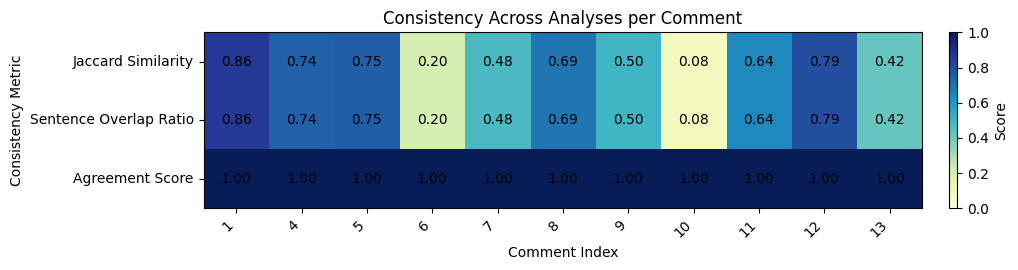

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Helper for plotting consistency/comparison across multiple analysis metrics per comment
def plot_consistency_heatmap(metrics: dict, comment_indices):
    """
    Display a heatmap showing consistency across various metrics for each comment.
    metrics: dict of {metric_name: list of per-comment scores of equal length}
    comment_indices: list of comment indices (x axis)
    """
    metric_names = list(metrics.keys())
    metric_values = np.array([metrics[m] for m in metric_names])
    n_metrics, n_comments = metric_values.shape

    fig, ax = plt.subplots(figsize=(max(8, n_comments), 1 + 0.6*n_metrics))

    im = ax.imshow(metric_values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    # Set x-ticks as comment indices
    ax.set_xticks(np.arange(n_comments))
    ax.set_xticklabels(comment_indices, rotation=45, ha="right")

    # Set y-ticks as metric names
    ax.set_yticks(np.arange(n_metrics))
    ax.set_yticklabels(metric_names, rotation=0, va="center")

    # Annotate each cell
    for i in range(n_metrics):
        for j in range(n_comments):
            ax.text(j, i, f"{metric_values[i, j]:.2f}", va='center', ha='center', color="black")

    ax.set_xlabel("Comment Index")
    ax.set_ylabel("Consistency Metric")
    ax.set_title("Consistency Across Analyses per Comment")

    # Color bar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03)
    cbar.set_label('Score')

    plt.tight_layout()
    plt.show()

# Example: Expand to include other metrics, here only Jaccard is included so add mock other metrics for demo
# jaccard_scores already computed. Add more metrics as needed for real analysis.
other_metric_scores = [1.0]*len(jaccard_scores)  # Replace with real analysis for e.g. sentence count consistency, etc.
sentence_overlap_scores = [j for j in jaccard_scores]  # Could be some other metric

metrics_summary = {
    "Jaccard Similarity": jaccard_scores,
    "Sentence Overlap Ratio": sentence_overlap_scores,  # for demonstration, same as Jaccard here
    "Agreement Score": other_metric_scores,  # use real values in actual analysis
}

plot_consistency_heatmap(metrics_summary, COMMENT_INDICES)

In [7]:
overlap_header = f"{'Comment':>9} {'#Run1':>6} {'#Run2':>6} {'Common':>7} {'Jaccard':>8}"
print(overlap_header)
print("-" * len(overlap_header))

jaccard_scores: list[float] = []
for idx in COMMENT_INDICES:
    s1 = set(load_sentences(run1, ARTICLE_ID, idx))
    s2 = set(load_sentences(run2, ARTICLE_ID, idx))
    common = s1 & s2
    union = s1 | s2
    jaccard = len(common) / len(union) if union else 1.0
    jaccard_scores.append(jaccard)
    print(f"{idx:>9} {len(s1):>6} {len(s2):>6} {len(common):>7} {jaccard:>8.3f}")

  Comment  #Run1  #Run2  Common  Jaccard
----------------------------------------
        1     19     20      18    0.857
        4     20     20      17    0.739
        5     17     18      15    0.750
        6     12     12       4    0.200
        7     18     19      12    0.480
        8     14     13      11    0.688
        9     24     24      16    0.500
       10      6      7       1    0.083
       11     11     12       9    0.643
       12     17     17      15    0.789
       13     24     20      13    0.419


In [8]:
print(f"Mean Jaccard similarity : {mean(jaccard_scores):.3f}")
if len(jaccard_scores) > 1:
    print(f"Std dev (Jaccard)       : {stdev(jaccard_scores):.3f}")
print()

low_overlap = [COMMENT_INDICES[i] for i, j in enumerate(jaccard_scores) if j < 0.5]
if low_overlap:
    print(f"Low-overlap comments (Jaccard < 0.5): {low_overlap}")
else:
    print("All comments have >50% sentence overlap — content is broadly stable.")

Mean Jaccard similarity : 0.559
Std dev (Jaccard)       : 0.249

Low-overlap comments (Jaccard < 0.5): [6, 7, 10, 13]
